# Tugas 2 — Perbandingan Centroid Awal K-Means (Baseline vs Outlier)

**Mata Kuliah:** Data Mining

## Deskripsi
Notebook ini **khusus membandingkan** dua pilihan centroid awal pada K-Means manual (K=2), memakai data pelanggan yang sama (Age & Income, tanpa standarisasi):

- **Skenario A — Baseline:** centroid awal **dekat data** → C1 = P1 (41,19), C2 = P2 (47,100).
- **Skenario B — Outlier:** centroid awal di **titik terjauh/outlier** → C1 = P5 (47,253), C2 = P9 (26,18).

Dua pertanyaan yang dijawab:
1. **Kalau centroid awal di outlier, apa yang berbeda?**
2. **Apakah anggota klaster berubah atau tetap sama?**

Detail tiap skenario: `Tugas2_KMeans_Elbow.ipynb` (baseline) dan `Tugas2_KMeans_Centroid_Outlier.ipynb` (outlier).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data pelanggan (sama dengan Tugas 2)
data = pd.DataFrame({
    'CustID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age':    [41, 47, 33, 29, 47, 40, 38, 42, 26, 47],
    'Income': [19, 100, 57, 19, 253, 81, 56, 64, 18, 115],
})
X = data[['Age', 'Income']].values.astype(float)
label_titik = [f'P{i+1}' for i in range(len(X))]
data

,CustID,Age,Income
0,1,41,19
1,2,47,100
2,3,33,57
3,4,29,19
4,5,47,253
5,6,40,81
6,7,38,56
7,8,42,64
8,9,26,18
9,10,47,115


In [2]:
def euclid(a, b):
    return np.sqrt(np.sum((np.array(a) - np.array(b)) ** 2))

def kmeans_manual(X, centroids_awal, max_iter=20):
    centroids = np.array(centroids_awal, dtype=float)
    history = []
    for it in range(max_iter):
        labels = np.array([int(np.argmin([euclid(x, c) for c in centroids])) for x in X])
        history.append({'centroids': centroids.copy(), 'labels': labels.copy()})
        new_c = np.array([X[labels == k].mean(axis=0) if (labels == k).any() else centroids[k]
                          for k in range(len(centroids))])
        if np.allclose(new_c, centroids):
            break
        centroids = new_c
    return centroids, labels, history

# Skenario A (baseline P1,P2) dan B (outlier P5,P9)
initA = [X[0], X[1]]    # P1, P2
initB = [X[4], X[8]]    # P5, P9
cA, labA, histA = kmeans_manual(X, initA)
cB, labB, histB = kmeans_manual(X, initB)

def anggota(lab):
    g = {0: [], 1: []}
    for i, k in enumerate(lab):
        g[k].append(label_titik[i])
    return g
gA, gB = anggota(labA), anggota(labB)
print('Skenario A (baseline):', gA)
print('Skenario B (outlier) :', gB)
print('Anggota klaster BERUBAH?', 'YA' if not np.array_equal(labA, labB) else 'TIDAK')

Skenario A (baseline): {0: ['P1', 'P3', 'P4', 'P6', 'P7', 'P8', 'P9'], 1: ['P2', 'P5', 'P10']}
Skenario B (outlier) : {0: ['P5'], 1: ['P1', 'P2', 'P3', 'P4', 'P6', 'P7', 'P8', 'P9', 'P10']}
Anggota klaster BERUBAH? YA


## Tabel Perbandingan

In [3]:
tabel = pd.DataFrame({
    'Aspek': [
        'Centroid awal C1', 'Centroid awal C2', 'Jumlah iterasi',
        'Centroid akhir C1', 'Centroid akhir C2',
        'Pembagian klaster', 'Anggota Klaster 1', 'Anggota Klaster 2', 'Kualitas hasil',
    ],
    'A — Baseline (P1, P2 dekat data)': [
        f'{tuple(initA[0])}', f'{tuple(initA[1])}', len(histA),
        f'{np.round(cA[0],1)}', f'{np.round(cA[1],1)}',
        f'{len(gA[0])} : {len(gA[1])}', ', '.join(gA[0]), ', '.join(gA[1]),
        'Baik (dua kelompok jelas)',
    ],
    'B — Outlier (P5, P9 terjauh)': [
        f'{tuple(initB[0])}', f'{tuple(initB[1])}', len(histB),
        f'{np.round(cB[0],1)}', f'{np.round(cB[1],1)}',
        f'{len(gB[0])} : {len(gB[1])}', ', '.join(gB[0]), ', '.join(gB[1]),
        'Buruk (outlier sendirian)',
    ],
})
with pd.option_context('display.max_colwidth', None):
    display(tabel)

,Aspek,"A — Baseline (P1, P2 dekat data)","B — Outlier (P5, P9 terjauh)"
0,Centroid awal C1,"(np.float64(41.0), np.float64(19.0))","(np.float64(47.0), np.float64(253.0))"
1,Centroid awal C2,"(np.float64(47.0), np.float64(100.0))","(np.float64(26.0), np.float64(18.0))"
2,Jumlah iterasi,4,2
3,Centroid akhir C1,[35.6 44.9],[ 47. 253.]
4,Centroid akhir C2,[ 47. 156.],[38.1 58.8]
5,Pembagian klaster,7 : 3,1 : 9
6,Anggota Klaster 1,"P1, P3, P4, P6, P7, P8, P9",P5
7,Anggota Klaster 2,"P2, P5, P10","P1, P2, P3, P4, P6, P7, P8, P9, P10"
8,Kualitas hasil,Baik (dua kelompok jelas),Buruk (outlier sendirian)


## Visualisasi Berdampingan

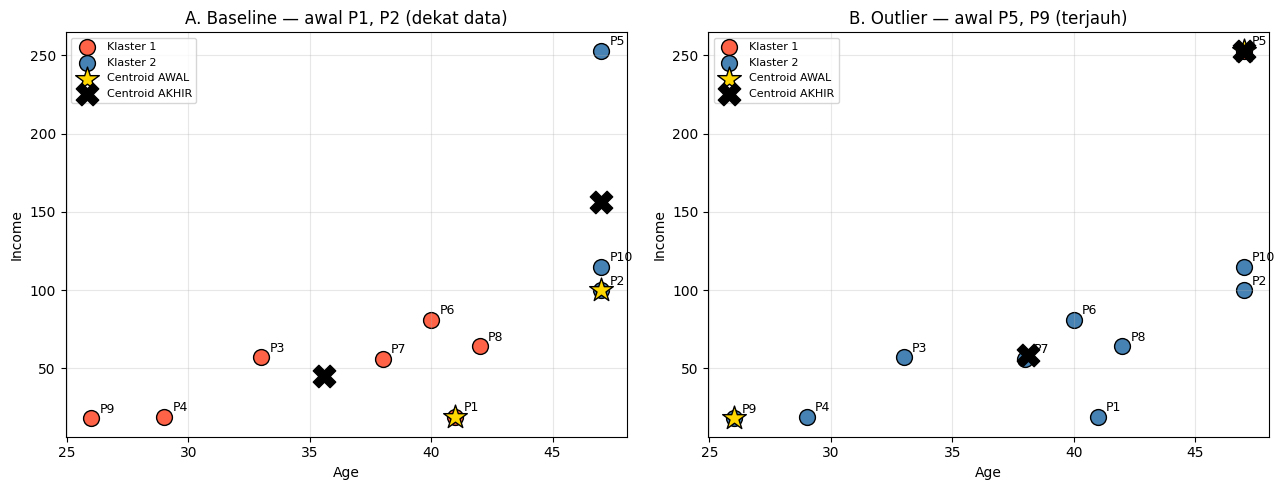

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
warna = ['tomato', 'steelblue']
for ax, (judul, lab, cen, init) in zip(axes, [
        ('A. Baseline — awal P1, P2 (dekat data)', labA, cA, initA),
        ('B. Outlier — awal P5, P9 (terjauh)', labB, cB, initB)]):
    for k in range(2):
        pts = X[lab == k]
        ax.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=130, edgecolors='k', label=f'Klaster {k+1}')
    ax.scatter([c[0] for c in init], [c[1] for c in init], marker='*', s=320,
               c='gold', edgecolors='k', label='Centroid AWAL', zorder=5)
    ax.scatter(cen[:, 0], cen[:, 1], marker='X', s=260, c='black', label='Centroid AKHIR', zorder=5)
    for i, x in enumerate(X):
        ax.annotate(label_titik[i], (x[0], x[1]), textcoords='offset points', xytext=(6, 4), fontsize=9)
    ax.set_xlabel('Age'); ax.set_ylabel('Income'); ax.set_title(judul)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Kesimpulan — Jawaban 2 Pertanyaan

**1. Kalau centroid awal di OUTLIER, apa yang berbeda?**
Outlier **P5 (47, 253)** menarik centroid ke dirinya sehingga menjadi **klaster sendirian (singleton)**. Centroid akhir berbeda (satu pusat tepat di P5), dan konvergen lebih cepat (2 vs 4 iterasi) — **bukan karena lebih baik**, tapi karena langsung terjebak solusi buruk: 1 klaster cuma outlier, 1 klaster menumpuk 9 titik.

**2. Anggota klaster berubah atau tidak?**
**BERUBAH total** — dari **7 : 3** (baseline) menjadi **1 : 9** (outlier).

**Pelajaran:** K-Means **sensitif terhadap inisialisasi centroid & outlier**, apalagi tanpa standarisasi (Income mendominasi jarak). Solusi: **standarisasi + k-means++ + n_init banyak**.